## Step 0: Importing pre-requisite libraries 

In [8]:
pip install -r requirements.txt

     ---------------------------------------- 8.3/8.3 MB 5.0 MB/s eta 0:00:00
     -------------------------------------- 101.7/101.7 MB 3.3 MB/s eta 0:00:00
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
     -------------------------------------- 306.1/306.1 kB 3.2 MB/s eta 0:00:00
     -------------------------------------- 474.0/474.0 kB 3.3 MB/s eta 0:00:00
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import numpy as np 
import matplotlib.pyplot as plt
import torch 

from data import loading_dataset, remap_labels, compute_stats, make_loaders, LABEL_NAMES
from model import MLPClassifier, CNN
from train import train_model, run_multi_seed, extract_cnn_embeddings, evaluate_accuracy

import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [ ]:
import zipfile  # upzipping dataset 

with zipfile.ZipFile("SignLanguageMNIST.zip", "r") as z:
    z.extractall("data")
    
!unzip SignLanguageMNIST.zip -d asl_data

'unzip' is not recognized as an internal or external command,
operable program or batch file.


## Step 1: Loading data into train - valid - test

In [11]:
X_train, y_train, X_test, y_test = loading_dataset()   # creating train and test datasets

# remapping labels for K-Y since J (and Z) are excluded from the dataset (motion-based signs)
y_train, y_test = remap_labels(y_train, y_test)

# splitting train and validation datasets (never touch test until final eval)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

num_classes = len(LABEL_NAMES)
print(f"train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}")
print(f"num classes: {num_classes}")
print(f"pixel mean/std (train): {compute_stats(X_train)}")

train: (21964, 28, 28), val: (5491, 28, 28), test: (7172, 28, 28)
num classes: 24
pixel mean/std (train): (np.float32(0.6247168), np.float32(0.1912184))


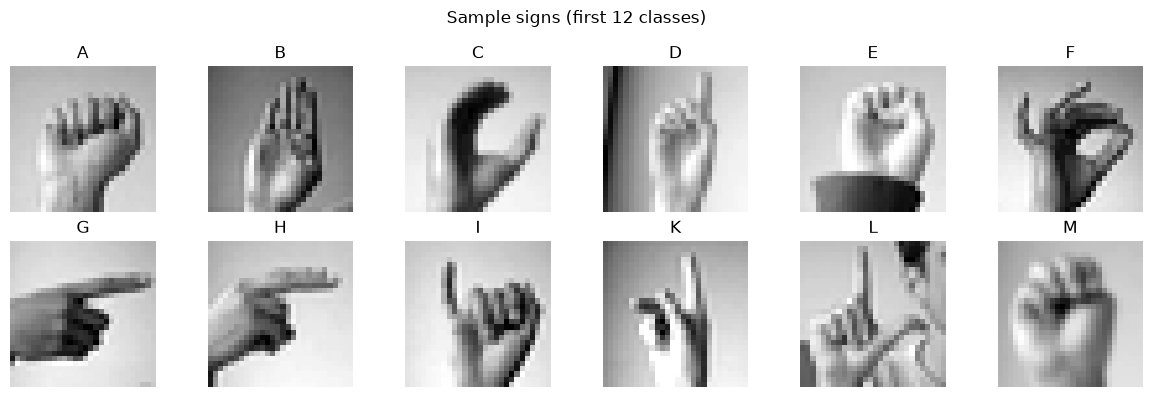

In [12]:
# look at a few examples before modeling
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for ax, cls in zip(axes.flat, range(12)):
    idx = np.where(y_train == cls)[0][0]
    ax.imshow(X_train[idx], cmap="gray")
    ax.set_title(LABEL_NAMES[cls])
    ax.axis("off")
plt.suptitle("Sample signs (first 12 classes)")
plt.tight_layout()
plt.show()

In [13]:
train_loader, val_loader, test_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test, batch_size=128
)

## Step 2: MLP

In [14]:
mlp_results = run_multi_seed(
    lambda: MLPClassifier(num_classes=num_classes),
    train_loader, val_loader, test_loader, device,
    seeds=(0, 1, 2), max_epochs=30, patience=3, optimizer_name="adam",
)
print(f"MLP baseline test acc: {mlp_results['mean']:.4f} +/- {mlp_results['std']:.4f}")
print(f"per-seed: {mlp_results['test_accs']}")

MLP baseline test acc: 0.7809 +/- 0.0042
per-seed: [0.7752370329057445, 0.7852760736196319, 0.782069157836029]


## Step 3: CNN

In [15]:
cnn_results = run_multi_seed(
    lambda: CNN(num_classes=num_classes),
    train_loader, val_loader, test_loader, device,
    seeds=(0, 1, 2), max_epochs=30, patience=3, optimizer_name="adam",
)
print(f"CNN test acc: {cnn_results['mean']:.4f} +/- {cnn_results['std']:.4f}")
print(f"per-seed: {cnn_results['test_accs']}")

CNN test acc: 0.8979 +/- 0.0081
per-seed: [0.8987730061349694, 0.8876185164528723, 0.9072783045175683]


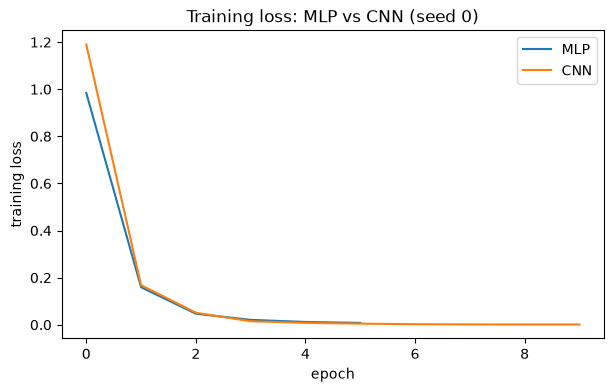

In [16]:
# overlay loss curves from one representative seed of each, for the report
plt.figure(figsize=(7, 4))
plt.plot(mlp_results["histories"][0]["train_losses"], label="MLP")
plt.plot(cnn_results["histories"][0]["train_losses"], label="CNN")
plt.xlabel("epoch")
plt.ylabel("training loss")
plt.title("Training loss: MLP vs CNN (seed 0)")
plt.legend()
plt.show()

## Step 4: CNN + XGBoost

In [17]:
hybrid_test_accs = []
for seed in cnn_results["seeds"]:
    cnn_model, _ = train_model(
        lambda: CNN(num_classes=num_classes),
        train_loader, val_loader, device, seed=seed, max_epochs=30, patience=3,
    )
    feats_train, labels_train = extract_cnn_embeddings(cnn_model, train_loader, device)
    feats_test, labels_test = extract_cnn_embeddings(cnn_model, test_loader, device)

    xgb_clf = xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        random_state=seed, eval_metric="mlogloss",
    )
    xgb_clf.fit(feats_train, labels_train)
    preds = xgb_clf.predict(feats_test)
    acc = accuracy_score(labels_test, preds)
    hybrid_test_accs.append(acc)

hybrid_test_accs = np.array(hybrid_test_accs)
print(f"CNN+XGBoost test acc: {hybrid_test_accs.mean():.4f} +/- {hybrid_test_accs.std():.4f}")
print(f"per-seed: {hybrid_test_accs.tolist()}")

CNN+XGBoost test acc: 0.8921 +/- 0.0042
per-seed: [0.8866424986056888, 0.8966815393195762, 0.8930563301728945]


## Step 5: Comparing above 3 models

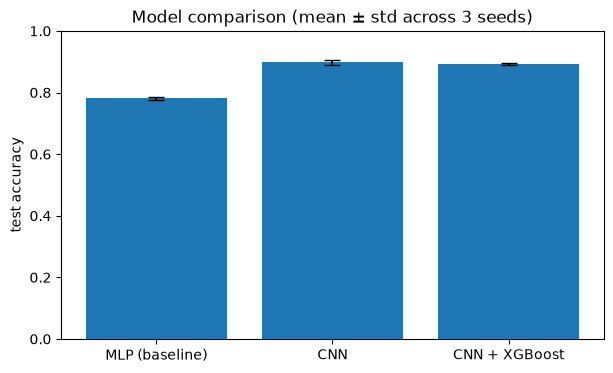

MLP (baseline): 0.7809 +/- 0.0042
CNN: 0.8979 +/- 0.0081
CNN + XGBoost: 0.8921 +/- 0.0042


In [18]:
names = ["MLP (baseline)", "CNN", "CNN + XGBoost"]
means = [mlp_results["mean"], cnn_results["mean"], hybrid_test_accs.mean()]
stds = [mlp_results["std"], cnn_results["std"], hybrid_test_accs.std()]

plt.figure(figsize=(7, 4))
plt.bar(names, means, yerr=stds, capsize=6)
plt.ylabel("test accuracy")
plt.title("Model comparison (mean ± std across 3 seeds)")
plt.ylim(0, 1)
plt.show()

for n, m, s in zip(names, means, stds):
    print(f"{n}: {m:.4f} +/- {s:.4f}")

## Step 6: Confusion matrix for the CNN

Retrain one CNN (seed 0) to inspect which letters it confuses most.

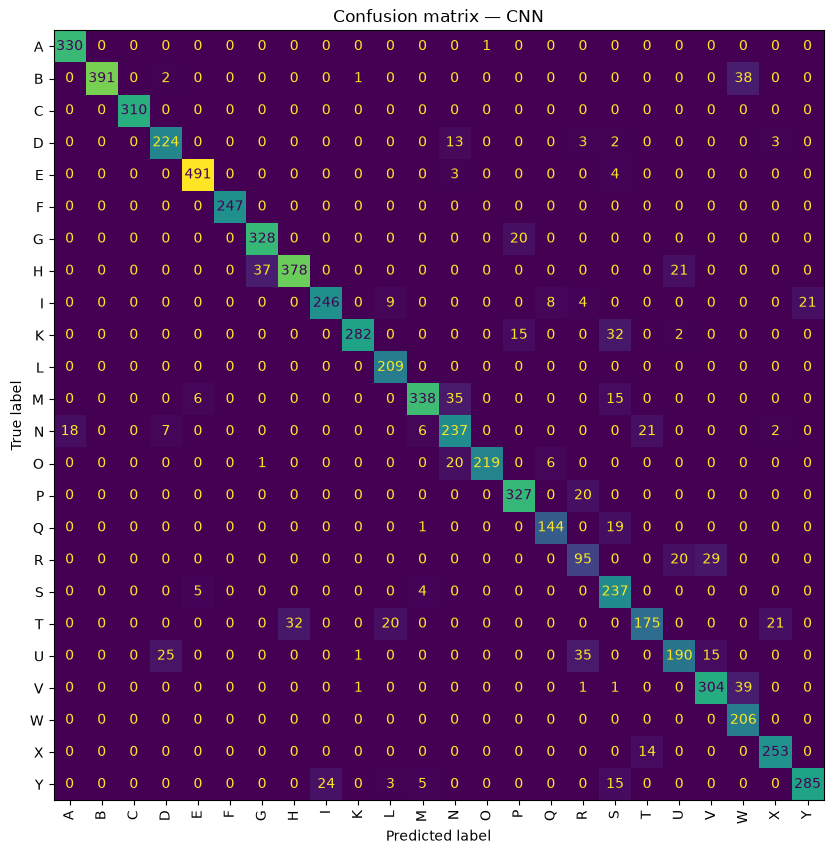

In [19]:
cnn_plain, _ = train_model(
    lambda: CNN(num_classes=num_classes),
    train_loader, val_loader, device, seed=0, max_epochs=30, patience=3,
)

preds_all, true_all = [], []
cnn_plain.eval()
with torch.no_grad():
    for X, y in test_loader:
        p = cnn_plain(X.to(device)).argmax(dim=1).cpu().numpy()
        preds_all.extend(p)
        true_all.extend(y.numpy())

cm = confusion_matrix(true_all, preds_all)
disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Confusion matrix — CNN")
plt.show()